In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../data/preprocessed_data.csv")

df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,Season
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2023,12,26,52,4,Tuesday,False,Winter
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2023,8,5,31,3,Saturday,True,Monsoon
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2024,3,11,11,1,Monday,False,Summer
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2023,10,27,43,4,Friday,False,Autumn
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2023,12,22,51,4,Friday,False,Winter


In [4]:
print(df.shape)

df.info()

df.head()

(100000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  str    
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  str    
 5   PaymentMethod       100000 non-null  str    
 6   StoreLocation       100000 non-null  str    
 7   ProductCategory     100000 non-null  str    
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
 10  Year                100000 non-null  int64  
 11  Month               100000 non-null  int64  
 12  Day                 100000 non-null  int64  
 13  Week                100000 non-null  int64  
 14  Quarter             100000 non-null  int64  
 15  DayOfWeek           100000 non-nu

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,Season
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2023,12,26,52,4,Tuesday,False,Winter
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2023,8,5,31,3,Saturday,True,Monsoon
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2024,3,11,11,1,Monday,False,Summer
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2023,10,27,43,4,Friday,False,Autumn
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2023,12,22,51,4,Friday,False,Winter


In [5]:
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
Year                  0
Month                 0
Day                   0
Week                  0
Quarter               0
DayOfWeek             0
Weekend               0
Season                0
dtype: int64

In [6]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [7]:
customer_data = df.groupby("CustomerID").agg({
    "TotalAmount": "sum",
    "Quantity": "sum",
    "TransactionDate": "count"
}).reset_index()

customer_data.rename(columns={
    "TransactionDate": "Frequency"
}, inplace=True)

customer_data.head()

,CustomerID,TotalAmount,Quantity,Frequency
0,14,256.232791,5,1
1,42,502.656523,7,1
2,49,21.399047,1,1
3,59,249.492696,12,2
4,65,548.006625,8,1


In [8]:
customer_data.columns = [
    "CustomerID",
    "TotalSpent",
    "QuantityPurchased",
    "Frequency"
]

customer_data.head()

,CustomerID,TotalSpent,QuantityPurchased,Frequency
0,14,256.232791,5,1
1,42,502.656523,7,1
2,49,21.399047,1,1
3,59,249.492696,12,2
4,65,548.006625,8,1


In [9]:
customer_data.describe()

,CustomerID,TotalSpent,QuantityPurchased,Frequency
count,95215.000000,95215.000000,95215.000000,95215.000000
mean,500172.700436,260.814950,5.261030,1.050255
std,288449.828783,197.112734,2.874849,0.226357
min,14.000000,8.274825,1.000000,1.000000
25%,250558.000000,99.493069,3.000000,1.000000
50%,499114.000000,210.700964,5.000000,1.000000
75%,750633.500000,378.626330,7.000000,1.000000
max,999997.000000,2002.072661,27.000000,4.000000


In [10]:
features = customer_data[
    ["TotalSpent",
     "QuantityPurchased",
     "Frequency"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

In [12]:
customer_data["Cluster"].value_counts()

Cluster
0    49781
2    40813
1     4621
Name: count, dtype: int64

In [13]:
customer_data.groupby("Cluster")[[
    "TotalSpent",
    "QuantityPurchased",
    "Frequency"
]].mean()

,TotalSpent,QuantityPurchased,Frequency
Cluster,,,
0,126.045412,3.109700,1.00000
1,503.230718,10.154728,2.03549
2,397.750710,7.330997,1.00000


In [14]:
cluster_names = {
    0: "Occasional",
    1: "High Value",
    2: "Loyal"
}

customer_data["CustomerGroup"] = customer_data["Cluster"].map(cluster_names)

customer_data.head()

,CustomerID,TotalSpent,QuantityPurchased,Frequency,Cluster,CustomerGroup
0,14,256.232791,5,1,0,Occasional
1,42,502.656523,7,1,2,Loyal
2,49,21.399047,1,1,0,Occasional
3,59,249.492696,12,2,1,High Value
4,65,548.006625,8,1,2,Loyal


In [15]:
customer_data["CustomerGroup"].value_counts()

CustomerGroup
Occasional    49781
Loyal         40813
High Value     4621
Name: count, dtype: int64

In [16]:
customer_data.groupby("CustomerGroup")[[
    "TotalSpent",
    "QuantityPurchased",
    "Frequency"
]].mean()

,TotalSpent,QuantityPurchased,Frequency
CustomerGroup,,,
High Value,503.230718,10.154728,2.03549
Loyal,397.750710,7.330997,1.00000
Occasional,126.045412,3.109700,1.00000


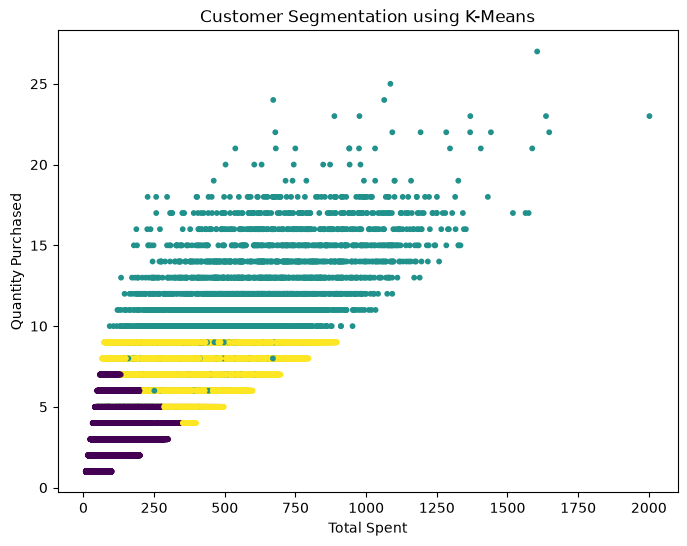

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data["TotalSpent"],
    customer_data["QuantityPurchased"],
    c=customer_data["Cluster"],
    cmap="viridis",
    s=10
)

plt.xlabel("Total Spent")
plt.ylabel("Quantity Purchased")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [18]:
customer_data.to_csv(
    "../data/customer_segmentation.csv",
    index=False
)

print("Customer Segmentation Data Saved Successfully!")

Customer Segmentation Data Saved Successfully!


In [19]:
customer_data.head(10)

,CustomerID,TotalSpent,QuantityPurchased,Frequency,Cluster,CustomerGroup
0,14,256.232791,5,1,0,Occasional
1,42,502.656523,7,1,2,Loyal
2,49,21.399047,1,1,0,Occasional
3,59,249.492696,12,2,1,High Value
4,65,548.006625,8,1,2,Loyal
5,87,41.515905,2,1,0,Occasional
6,96,194.356816,4,1,0,Occasional
7,98,166.934647,6,1,0,Occasional
8,100,710.062576,8,1,2,Loyal
9,101,364.974295,9,1,2,Loyal
